In [2]:
import sys
from pathlib import Path

CODE_DIR = (Path.cwd().parent).resolve()
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

from cloudprompts.evaluation import evaluate_segmentation

In [3]:
from pathlib import Path

RUNS_ROOT = Path("../inference/clipseg_cloudsen12plus_lora_low_data/masks").resolve()

OUT_ROOT = Path("../inference/clipseg_cloudsen12plus_lora_low_data").resolve()

GT_DIR = Path("../data/cloudsen12plus/export_p509_high_npz/test/masks").resolve()

GT_KEY = "mask"
PRED_KEY = "mask"

GT_EXT = ".npz"
PRED_EXT = ".npz"

NUM_CLASSES = 4
CLASS_NAMES = ["clear", "thick_cloud", "thin_cloud", "cloud_shadow"]

IGNORE_INDEX = None
STRICT = True

print("RUNS_ROOT:", RUNS_ROOT, "exists:", RUNS_ROOT.exists())
print("GT_DIR   :", GT_DIR, "exists:", GT_DIR.exists())
print("OUT_ROOT :", OUT_ROOT, "exists:", OUT_ROOT.exists())

RUNS_ROOT: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_lora_low_data/masks exists: True
GT_DIR   : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/data/cloudsen12plus/export_p509_high_npz/test/masks exists: True
OUT_ROOT : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_lora_low_data exists: True


In [4]:
import re

def pick_checkpoint(seed_dir: Path) -> Path:
    """Pick the latest checkpoint-* (by step number)."""
    ckpts = list(seed_dir.glob("checkpoint-*"))
    if not ckpts:
        raise FileNotFoundError(f"No checkpoint-* found in {seed_dir}")

    def step(p: Path) -> int:
        m = re.search(r"checkpoint-(\d+)", p.name)
        return int(m.group(1)) if m else -1

    ckpts.sort(key=step)
    return ckpts[-1]


def safe_rename(src: Path, dst: Path) -> None:
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        dst.unlink()
    src.rename(dst)

In [5]:
def run_all_with_evaluate_segmentation():
    OUT_ROOT.mkdir(parents=True, exist_ok=True)

    pct_dirs = sorted([p for p in RUNS_ROOT.glob("pct_*") if p.is_dir()])
    if not pct_dirs:
        raise FileNotFoundError(f"No pct_* folders found under {RUNS_ROOT}")

    print(f"[INFO] Found {len(pct_dirs)} pct folders")

    for pct_dir in pct_dirs:
        out_pct_dir = OUT_ROOT / pct_dir.name
        out_pct_dir.mkdir(parents=True, exist_ok=True)

        seed_dirs = sorted([s for s in pct_dir.glob("seed_*") if s.is_dir()])
        if not seed_dirs:
            print(f"[WARN] No seed_* under {pct_dir}, skipping.")
            continue

        print(f"\n[INFO] ===== {pct_dir.name} (seeds={len(seed_dirs)}) =====")

        for seed_dir in seed_dirs:
            seed_name = seed_dir.name
            ckpt_dir = pick_checkpoint(seed_dir)
            pred_dir = ckpt_dir / "masks"

            if not pred_dir.exists():
                print(f"[WARN] Missing masks dir: {pred_dir} (skipping)")
                continue

            stage = f"{seed_name}"

            result = evaluate_segmentation(
                gt_dir=GT_DIR,
                pred_dir=pred_dir,
                model="clipseg",
                dataset="cloudsen12plus",
                stage=stage,
                num_classes=NUM_CLASSES,
                class_names=CLASS_NAMES,
                run_root=out_pct_dir,
                gt_key=GT_KEY,
                pred_key=PRED_KEY,
                gt_ext=GT_EXT,
                pred_ext=PRED_EXT,
                ignore_index=IGNORE_INDEX,
                strict=STRICT,
            )

            miou_src = Path(result["miou_csv"])
            cm_src = Path(result["cm_csv"])

            miou_dst = out_pct_dir / f"{seed_name}_miou.csv"
            cm_dst = out_pct_dir / f"{seed_name}_cm.csv"

            safe_rename(miou_src, miou_dst)
            safe_rename(cm_src, cm_dst)

            print(f"[OK] {pct_dir.name}/{seed_name} -> {miou_dst.name}, {cm_dst.name}")

    print("\n[DONE] All CSVs generated into ./inference/pct_x folders.")


In [ ]:
run_all_with_evaluate_segmentation()

In [7]:
import re
import pandas as pd
import numpy as np

In [11]:
INFER_ROOT = Path("../inference/clipseg_cloudsen12plus_lora_low_data").resolve()

OUT_CSV = Path("../inference/clipseg_cloudsen12plus_lora_low_data/low_data_ladder.csv").resolve()

PCT_MIN = 0.1
PCT_MAX = 90

print("INFER_ROOT:", INFER_ROOT, "exists:", INFER_ROOT.exists())

INFER_ROOT: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_lora_low_data exists: True


In [16]:
def parse_pct_num(pct_name: str) -> float:
    """
    Accepts: pct_0.1, pct_1, pct_10, pct_50, pct_10.5
    Rejects: pct_.1 (unless you choose to allow), pct_ (empty), pct_1.2.3
    """
    m = re.match(r"^pct_(\d+(?:\.\d+)?)$", pct_name)
    if not m:
        raise ValueError(f"Bad pct folder name: {pct_name}")
    return float(m.group(1))

def read_aggregate_row(csv_path: Path) -> pd.Series:
    df = pd.read_csv(csv_path)
    if "id" not in df.columns:
        raise ValueError(f"'id' column missing in {csv_path}")
    agg = df[df["id"] == "__aggregate__"]
    if agg.empty:
        raise ValueError(f"No __aggregate__ row found in {csv_path}")
    if len(agg) > 1:
        raise ValueError(f"Multiple __aggregate__ rows found in {csv_path}")
    return agg.iloc[0]

def list_pct_dirs(infer_root: Path, pct_min: float, pct_max: float):
    out = []
    for d in infer_root.glob("pct_*"):
        if not d.is_dir():
            continue
        pct = parse_pct_num(d.name)
        if pct_min <= pct <= pct_max:
            out.append((pct, d))
    out.sort(key=lambda x: x[0])
    return out


In [17]:
pct_dirs = list_pct_dirs(INFER_ROOT, PCT_MIN, PCT_MAX)
if not pct_dirs:
    raise FileNotFoundError(f"No pct folders found in {INFER_ROOT} within {PCT_MIN}-{PCT_MAX}")

seed_records = []

for pct, pct_dir in pct_dirs:
    miou_files = sorted(pct_dir.glob("seed_*_miou.csv"))
    cm_files = sorted(pct_dir.glob("seed_*_cm.csv"))

    miou_map = {f.name.replace("_miou.csv", ""): f for f in miou_files}
    cm_map   = {f.name.replace("_cm.csv", ""): f for f in cm_files}

    seeds = sorted(set(miou_map.keys()) & set(cm_map.keys()))
    if not seeds:
        print(f"[WARN] No matching seed_*_miou.csv and seed_*_cm.csv in {pct_dir}")
        continue

    for seed in seeds:
        miou_path = miou_map[seed]
        cm_path   = cm_map[seed]

        miou_agg = read_aggregate_row(miou_path)
        cm_agg   = read_aggregate_row(cm_path)

        metric_cols = [c for c in miou_agg.index if c != "id"]
        metrics = {c: float(miou_agg[c]) for c in metric_cols}

        cm_cols = [c for c in cm_agg.index if c != "id"]
        cm_counts = {c: int(cm_agg[c]) for c in cm_cols}

        seed_records.append({
            "pct": pct,
            "seed": seed,
            **metrics,
            **cm_counts,
        })

seed_df = pd.DataFrame(seed_records)
print("Per-seed table shape:", seed_df.shape)
seed_df.head(3)


Per-seed table shape: (60, 24)


,pct,seed,miou,pixel_acc,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow,cm_t0_p0,cm_t0_p1,...,cm_t1_p2,cm_t1_p3,cm_t2_p0,cm_t2_p1,cm_t2_p2,cm_t2_p3,cm_t3_p0,cm_t3_p1,cm_t3_p2,cm_t3_p3
0,0.1,seed_11,0.271960,0.543809,0.580533,0.326695,0.099005,0.081608,99966831,8460133,...,27180273,3807230,9228210,2802756,7831990,2122112,13044710,2686125,5767818,2763050
1,0.1,seed_111,0.268914,0.507017,0.552930,0.327935,0.093353,0.101437,88072826,8561344,...,33022461,4808476,7097454,2731115,8916953,3239546,9250997,2775274,8213824,4021608
2,0.1,seed_22,0.283255,0.560371,0.620720,0.346840,0.089834,0.075628,103966468,6303322,...,29712498,3562534,9740535,2344073,7334093,2566367,11019367,2854794,7797768,2589774


In [18]:
all_cols = set(seed_df.columns)
metric_cols = [c for c in seed_df.columns if (c not in ["pct", "seed"]) and (not c.startswith("cm_"))]
cm_cols = [c for c in seed_df.columns if c.startswith("cm_")]

metric_mean = seed_df.groupby("pct")[metric_cols].mean().add_suffix("_mean")
metric_std  = seed_df.groupby("pct")[metric_cols].std(ddof=1).add_suffix("_std")

cm_sum = seed_df.groupby("pct")[cm_cols].sum().add_suffix("_sum")

n_seeds = seed_df.groupby("pct")["seed"].nunique().to_frame("n_seeds")

pct_df = pd.concat([n_seeds, metric_mean, metric_std, cm_sum], axis=1).reset_index()
pct_df = pct_df.sort_values("pct")

print("Per-pct summary shape:", pct_df.shape)
pct_df.head()


Per-pct summary shape: (6, 30)


,pct,n_seeds,miou_mean,pixel_acc_mean,iou_clear_mean,iou_thick_cloud_mean,iou_thin_cloud_mean,iou_cloud_shadow_mean,miou_std,pixel_acc_std,...,cm_t1_p2_sum,cm_t1_p3_sum,cm_t2_p0_sum,cm_t2_p1_sum,cm_t2_p2_sum,cm_t2_p3_sum,cm_t3_p0_sum,cm_t3_p1_sum,cm_t3_p2_sum,cm_t3_p3_sum
0,0.1,10,0.269219,0.534832,0.587705,0.318992,0.091431,0.078748,0.009396,0.027644,...,308788311,39781954,90256679,25830315,78304771,25458915,112528845,27988530,73067755,29031900
1,0.5,10,0.262399,0.626186,0.619056,0.386373,0.034816,0.009353,0.009344,0.039632,...,102313866,5315626,176227291,19564566,21161162,2897661,190184750,26133184,23734175,2564921
2,1.0,10,0.301695,0.690638,0.649085,0.529780,0.012980,0.014936,0.014967,0.013746,...,9013455,634984,188153056,28344260,3217394,135970,198156741,35798273,5019364,3642652
3,5.0,10,0.434950,0.755622,0.727147,0.649003,0.093332,0.270318,0.064952,0.039541,...,15730907,24267387,140162836,43333273,25388565,10966006,100725925,49426679,6544056,85920370
4,10.0,10,0.482495,0.784513,0.759561,0.691488,0.146401,0.332530,0.021771,0.008712,...,16299288,26867639,125660220,43789851,38852213,11548396,82309352,49409255,6561926,104336497


In [19]:
pct_df.to_csv(OUT_CSV, index=False)
print("Wrote:", OUT_CSV)

Wrote: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_lora_low_data/low_data_ladder.csv


In [20]:
import matplotlib.pyplot as plt

CODE_DIR = (Path.cwd().parent).resolve()
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

In [22]:
def pick_path(local_name: str, fallback: str) -> Path:
    p = Path(local_name)
    return p if p.exists() else Path(fallback)

LOW_DATA_CSV = pick_path("low_data_ladder.csv", "../inference/clipseg_cloudsen12plus_lora_low_data/low_data_ladder.csv")
ZS_MIOU_CSV  = pick_path("miou_clipseg_cloudsen12plus_zs_eval.csv",  "../inference/clipseg_cloudsen12plus_zs/miou_clipseg_cloudsen12plus_zs_eval.csv")
LORA_MIOU_CSV = pick_path("miou_clipseg_cloudsen12plus_lora_eval.csv", "../inference/clipseg_cloudsen12plus_lora/miou_clipseg_cloudsen12plus_lora_eval.csv")

low_df = pd.read_csv(LOW_DATA_CSV)
zs_df  = pd.read_csv(ZS_MIOU_CSV)
lora_df = pd.read_csv(LORA_MIOU_CSV)

print("LOW_DATA_CSV:", LOW_DATA_CSV)
print("ZS_MIOU_CSV :", ZS_MIOU_CSV)
print("LORA_MIOU_CSV:", LORA_MIOU_CSV)

display(low_df.head(3))
display(zs_df.tail(3))
display(lora_df.tail(3))


LOW_DATA_CSV: ../inference/clipseg_cloudsen12plus_lora_low_data/low_data_ladder.csv
ZS_MIOU_CSV : ../inference/clipseg_cloudsen12plus_zs/miou_clipseg_cloudsen12plus_zs_eval.csv
LORA_MIOU_CSV: ../inference/clipseg_cloudsen12plus_lora/miou_clipseg_cloudsen12plus_lora_eval.csv


,pct,n_seeds,miou_mean,pixel_acc_mean,iou_clear_mean,iou_thick_cloud_mean,iou_thin_cloud_mean,iou_cloud_shadow_mean,miou_std,pixel_acc_std,...,cm_t1_p2_sum,cm_t1_p3_sum,cm_t2_p0_sum,cm_t2_p1_sum,cm_t2_p2_sum,cm_t2_p3_sum,cm_t3_p0_sum,cm_t3_p1_sum,cm_t3_p2_sum,cm_t3_p3_sum
0,0.1,10,0.269219,0.534832,0.587705,0.318992,0.091431,0.078748,0.009396,0.027644,...,308788311,39781954,90256679,25830315,78304771,25458915,112528845,27988530,73067755,29031900
1,0.5,10,0.262399,0.626186,0.619056,0.386373,0.034816,0.009353,0.009344,0.039632,...,102313866,5315626,176227291,19564566,21161162,2897661,190184750,26133184,23734175,2564921
2,1.0,10,0.301695,0.690638,0.649085,0.529780,0.012980,0.014936,0.014967,0.013746,...,9013455,634984,188153056,28344260,3217394,135970,198156741,35798273,5019364,3642652


,id,miou,pixel_acc,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow
973,ROI_9795__20200617T064631_20200617T064630_T43WER,0.319882,0.568077,0.463474,0.571132,0.00000,0.244920
974,ROI_9795__20200722T064629_20200722T064811_T43WER,0.399528,0.839676,0.842845,0.523046,0.00000,0.232219
975,__aggregate__,0.255040,0.468206,0.520532,0.277302,0.08984,0.132486


,id,miou,pixel_acc,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow
973,ROI_9795__20200617T064631_20200617T064630_T43WER,0.734480,0.872169,0.704978,0.876189,NaN,0.622272
974,ROI_9795__20200722T064629_20200722T064811_T43WER,0.476660,0.875843,0.864829,0.660689,0.000000,0.381124
975,__aggregate__,0.599132,0.838515,0.826941,0.748752,0.381977,0.438855


In [23]:
def get_agg_row(miou_df: pd.DataFrame) -> pd.Series:
    if "id" not in miou_df.columns:
        raise ValueError("Expected 'id' column in miou CSV")
    agg = miou_df[miou_df["id"] == "__aggregate__"]
    if agg.empty:
        raise ValueError("No __aggregate__ row found")
    return agg.iloc[0]

zs_agg  = get_agg_row(zs_df)
lora_agg = get_agg_row(lora_df)

print("ZS aggregate:", zs_agg.to_dict())
print("LORA aggregate:", lora_agg.to_dict())

ZS aggregate: {'id': '__aggregate__', 'miou': 0.2550400406013244, 'pixel_acc': 0.4682058520194812, 'iou_clear': 0.520532380887666, 'iou_thick_cloud': 0.277302215426787, 'iou_thin_cloud': 0.0898395431914562, 'iou_cloud_shadow': 0.1324860228993884}
LORA aggregate: {'id': '__aggregate__', 'miou': 0.5991315104337002, 'pixel_acc': 0.8385149833483574, 'iou_clear': 0.826941420264013, 'iou_thick_cloud': 0.7487520800788301, 'iou_thin_cloud': 0.3819771998563531, 'iou_cloud_shadow': 0.4388553415356047}


In [28]:
low_df2 = low_df.copy()
if "pct" not in low_df2.columns:
    raise ValueError("low_data_ladder.csv must have a 'pct' column")

low_df2["pct"] = low_df2["pct"].astype(float)
low_df2 = low_df2.sort_values("pct")

low_df2 = low_df2[(low_df2["pct"] >= 0.1) & (low_df2["pct"] <= 90)]

rows = []

rows.append({
    "x_label": "ZS",
    "pct": 0,
    "miou": float(zs_agg["miou"]),
    "miou_std": 0.0,
    "iou_clear": float(zs_agg["iou_clear"]),
    "iou_clear_std": 0.0,
    "iou_thick_cloud": float(zs_agg["iou_thick_cloud"]),
    "iou_thick_cloud_std": 0.0,
    "iou_thin_cloud": float(zs_agg["iou_thin_cloud"]),
    "iou_thin_cloud_std": 0.0,
    "iou_cloud_shadow": float(zs_agg["iou_cloud_shadow"]),
    "iou_cloud_shadow_std": 0.0,
})

for _, r in low_df2.iterrows():
    pct = float(r["pct"])
    rows.append({
        "x_label": f"{pct}%",
        "pct": pct,
        "miou": float(r["miou_mean"]),
        "miou_std": float(r["miou_std"]),
        "iou_clear": float(r["iou_clear_mean"]),
        "iou_clear_std": float(r["iou_clear_std"]),
        "iou_thick_cloud": float(r["iou_thick_cloud_mean"]),
        "iou_thick_cloud_std": float(r["iou_thick_cloud_std"]),
        "iou_thin_cloud": float(r["iou_thin_cloud_mean"]),
        "iou_thin_cloud_std": float(r["iou_thin_cloud_std"]),
        "iou_cloud_shadow": float(r["iou_cloud_shadow_mean"]),
        "iou_cloud_shadow_std": float(r["iou_cloud_shadow_std"]),
    })

rows.append({
    "x_label": "LoRA",
    "pct": 100,
    "miou": float(lora_agg["miou"]),
    "miou_std": 0.0,
    "iou_clear": float(lora_agg["iou_clear"]),
    "iou_clear_std": 0.0,
    "iou_thick_cloud": float(lora_agg["iou_thick_cloud"]),
    "iou_thick_cloud_std": 0.0,
    "iou_thin_cloud": float(lora_agg["iou_thin_cloud"]),
    "iou_thin_cloud_std": 0.0,
    "iou_cloud_shadow": float(lora_agg["iou_cloud_shadow"]),
    "iou_cloud_shadow_std": 0.0,
})

ladder_df = pd.DataFrame(rows)
ladder_df["x"] = np.arange(len(ladder_df))

display(ladder_df[["x_label","miou","miou_std","iou_clear","iou_thick_cloud","iou_thin_cloud","iou_cloud_shadow"]])


,x_label,miou,miou_std,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow
0,ZS,0.255040,0.000000,0.520532,0.277302,0.089840,0.132486
1,0.1%,0.269219,0.009396,0.587705,0.318992,0.091431,0.078748
2,0.5%,0.262399,0.009344,0.619056,0.386373,0.034816,0.009353
3,1.0%,0.301695,0.014967,0.649085,0.529780,0.012980,0.014936
4,5.0%,0.434950,0.064952,0.727147,0.649003,0.093332,0.270318
5,10.0%,0.482495,0.021771,0.759561,0.691488,0.146401,0.332530
6,50.0%,0.564985,0.019513,0.808165,0.730722,0.305998,0.415056
7,LoRA,0.599132,0.000000,0.826941,0.748752,0.381977,0.438855


In [29]:
def plot_ladder(df: pd.DataFrame, metric: str, metric_std: str, title: str, ylabel: str):
    x = df["x"].to_numpy()
    y = df[metric].to_numpy()
    yerr = df[metric_std].to_numpy() if metric_std in df.columns else None

    plt.figure(figsize=(9, 4.5))
    plt.step(x, y, where="mid")
    plt.plot(x, y, marker="o")

    if yerr is not None:
        plt.errorbar(x, y, yerr=yerr, fmt="none", capsize=3)

    plt.xticks(x, df["x_label"].tolist(), rotation=0)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


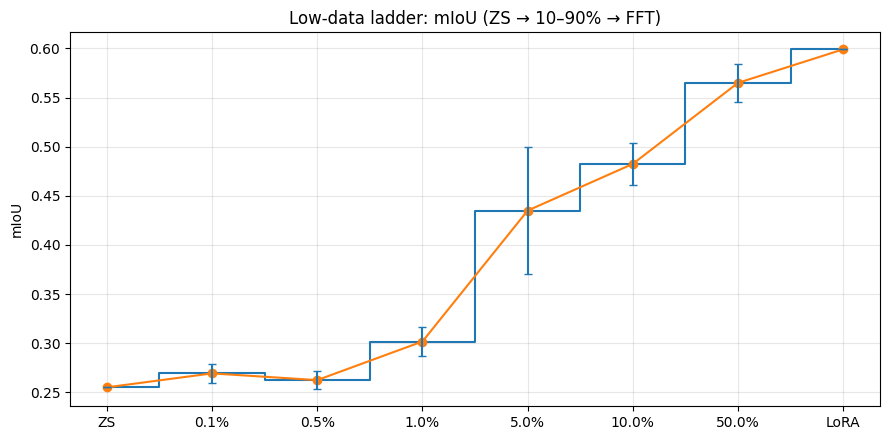

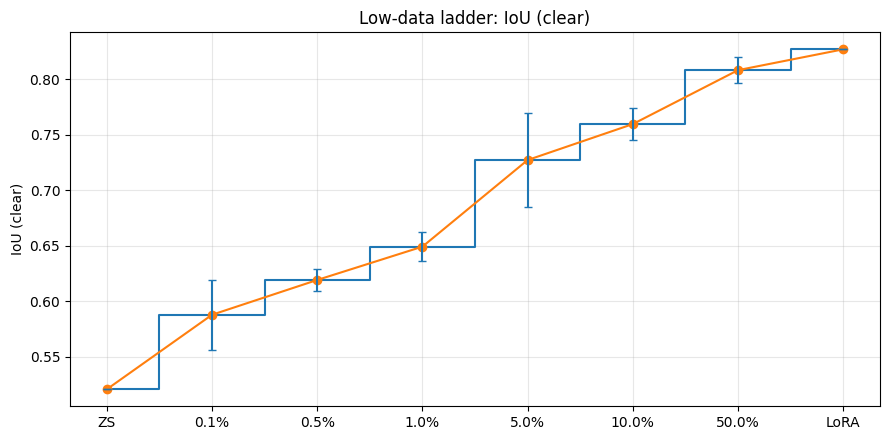

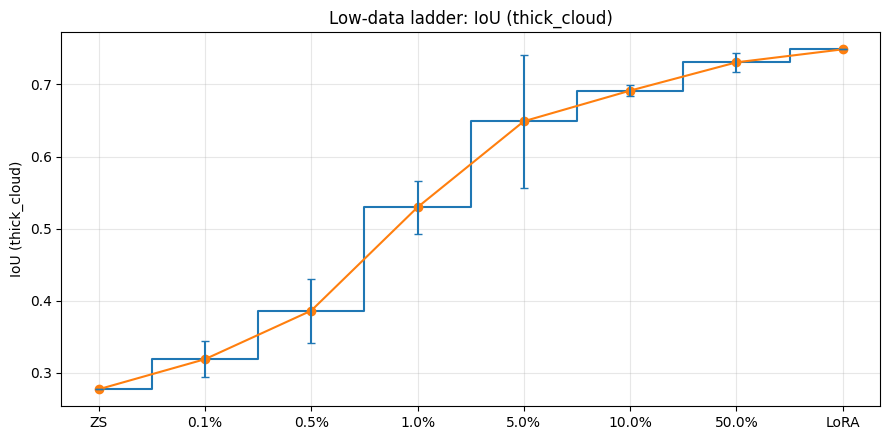

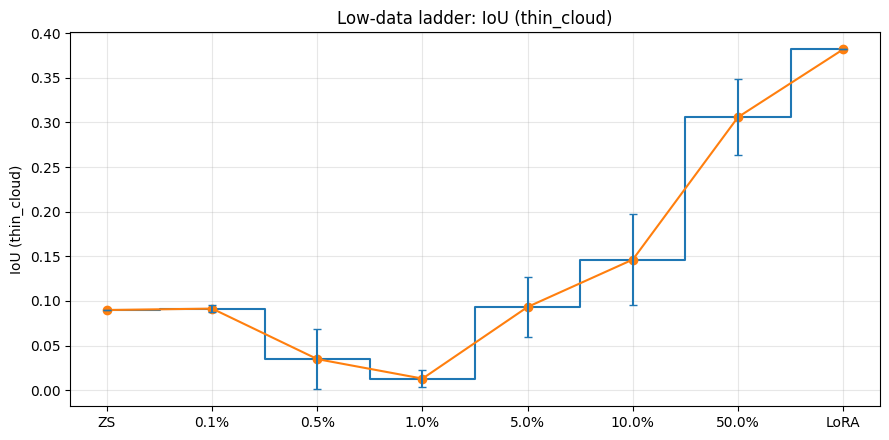

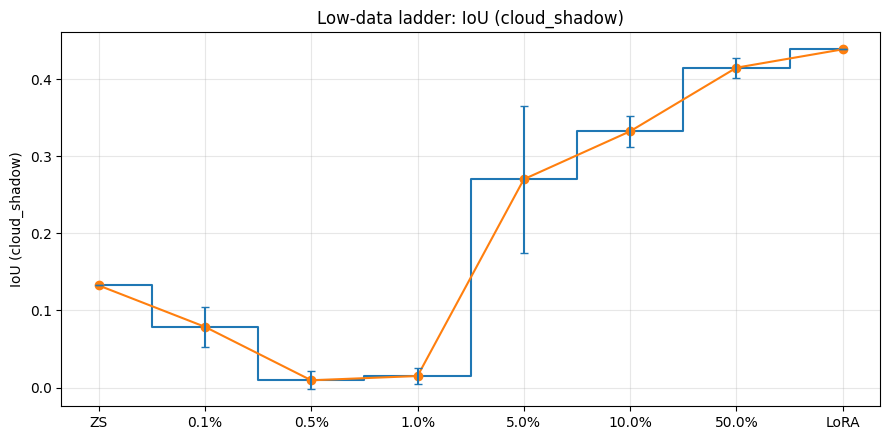

In [30]:
plot_ladder(
    ladder_df,
    metric="miou",
    metric_std="miou_std",
    title="Low-data ladder: mIoU (ZS → 10–90% → FFT)",
    ylabel="mIoU",
)

plot_ladder(
    ladder_df,
    metric="iou_clear",
    metric_std="iou_clear_std",
    title="Low-data ladder: IoU (clear)",
    ylabel="IoU (clear)",
)

plot_ladder(
    ladder_df,
    metric="iou_thick_cloud",
    metric_std="iou_thick_cloud_std",
    title="Low-data ladder: IoU (thick_cloud)",
    ylabel="IoU (thick_cloud)",
)

plot_ladder(
    ladder_df,
    metric="iou_thin_cloud",
    metric_std="iou_thin_cloud_std",
    title="Low-data ladder: IoU (thin_cloud)",
    ylabel="IoU (thin_cloud)",
)

plot_ladder(
    ladder_df,
    metric="iou_cloud_shadow",
    metric_std="iou_cloud_shadow_std",
    title="Low-data ladder: IoU (cloud_shadow)",
    ylabel="IoU (cloud_shadow)",
)
